# Breast Tumour 3D Segmentation — Full Pipeline Notebook

**Model:** MONAI ResNet UNet 3D  
**Data:** Preprocessed `.npy` volumes (1.5mm isotropic, breast-mask cropped)  
**Input:** 3-channel DCE-MRI (P1 early, P2 mid, P3 late contrast)  
**GPU:** RTX 2000 Ada 16GB (or RTX 3050 6GB with reduced channels)  

### Cells in this notebook
```
Cell 1  — Environment check + GPU info
Cell 2  — Dataset inspection (shapes, tumor stats)
Cell 3  — Visualise raw preprocessed volumes with GT overlay
Cell 4  — Model definition + parameter count
Cell 5  — Training curves (loss, Dice, Precision, Recall)
Cell 6  — Threshold sweep on validation set
Cell 7  — Inference on test set (sliding window + TTA)
Cell 8  — GT mask vs Predicted mask overlay (slice + probability map)
Cell 9  — 3D volume rendering: GT vs prediction (MIP + surface)
Cell 10 — Per-patient evaluation table
Cell 11 — Full summary card
```
> **Note:** Training is NOT run from this notebook. Run `train_3d.py` separately.  
> This notebook loads the already-trained model and evaluates it.


In [1]:
# ============================================================
# CELL 1 — Environment check + GPU info
# ============================================================
import os, sys, warnings
import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from IPython.display import display
import pandas as pd

warnings.filterwarnings('ignore')

# ---- GPU ----
assert torch.cuda.is_available(), "No CUDA GPU found — this notebook requires a GPU."
device    = torch.device('cuda')
torch.cuda.set_device(0)
gpu_name  = torch.cuda.get_device_name(0)
vram_gb   = torch.cuda.get_device_properties(0).total_memory / 1e9
is_ada    = 'Ada' in gpu_name or 'RTX 20' in gpu_name
is_3050   = '3050' in gpu_name

print('=' * 55)
print('  3D Segmentation Pipeline — Environment')
print('=' * 55)
print(f'  PyTorch  : {torch.__version__}')
print(f'  GPU      : {gpu_name}')
print(f'  VRAM     : {vram_gb:.1f} GB')
print(f'  Device   : {device}')

import monai
print(f'  MONAI    : {monai.__version__}')

# ── PROJECT ROOT ───────────────────────────────────────────────────
# Your notebook is inside notebooks/ subfolder.
# PROJECT_ROOT must point to D:\Breast_Tumor_AI_Project (one level up).
# We detect this automatically — works whether you open the notebook
# from VS Code, Jupyter Lab, or double-click.

_nb_dir      = os.path.dirname(os.path.abspath('__file__'))   # notebooks/ dir
_cwd         = os.getcwd()

# If CWD already ends with Breast_Tumor_AI_Project use it directly,
# otherwise go one level up from notebooks/
if os.path.basename(_cwd).lower() in ('notebooks', 'notebook'):
    PROJECT_ROOT = os.path.dirname(_cwd)
elif not os.path.exists(os.path.join(_cwd, 'src\segmentation')):
    # CWD doesn't have the source folder — try parent
    _parent = os.path.dirname(_cwd)
    if os.path.exists(os.path.join(_parent, 'src\segmentation')):
        PROJECT_ROOT = _parent
    else:
        # Fallback — hardcoded absolute path
        PROJECT_ROOT = r"D:\Breast_Tumor_AI_Project"
else:
    PROJECT_ROOT = _cwd

# Force correct CWD so all relative file operations work
os.chdir(PROJECT_ROOT)

print(f'  Project  : {PROJECT_ROOT}')
print(f'  CWD set  : {os.getcwd()}')

# ── SOURCE PATH ────────────────────────────────────────────────────
# data_3d.py, model_3d.py, train_3d.py all live here:
SRC_DIR = os.path.join(PROJECT_ROOT, 'src\segmentation')

if not os.path.exists(SRC_DIR):
    raise FileNotFoundError(
        f"Source folder not found: {SRC_DIR}\n"
        f"Edit PROJECT_ROOT above to point to D:\\Breast_Tumor_AI_Project"
    )

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

print(f'  Src dir  : {SRC_DIR}')

# Quick import test
try:
    from data_3d import PATCH_SIZE, _build_data_list, NpyDataset, get_val_transforms
    from model_3d import get_model, MODEL_CONFIG
    print(f'  Imports  : OK  (PATCH_SIZE={PATCH_SIZE})')
except ImportError as e:
    raise ImportError(
        f"Cannot import data_3d / model_3d: {e}\n"
        f"Check that {SRC_DIR} contains data_3d.py and model_3d.py"
    )

# ── PATHS ──────────────────────────────────────────────────────────
PREPROCESSED_ROOT = os.path.join(PROJECT_ROOT, 'data', 'patients_combined')
MODEL_DIR         = os.path.join(PROJECT_ROOT, 'models', 'segmentation_3d')
OUTPUT_DIR        = os.path.join(PROJECT_ROOT, 'outputs', 'segmentation_3d_predictions')
HISTORY_FILE      = os.path.join(PROJECT_ROOT, 'training_history_3d.npy')
BASELINE_2D_DICE  = 0.7501

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Verify preprocessed data exists
if not os.path.exists(PREPROCESSED_ROOT):
    print(f'  WARNING: Preprocessed data not found at {PREPROCESSED_ROOT}')
    print(f'           Run prepare_3d_offline.py first.')
else:
    # Count patients quickly
    for split in ['train', 'val', 'test']:
        sp = os.path.join(PREPROCESSED_ROOT, split)
        n  = len([d for d in os.listdir(sp) if os.path.isdir(os.path.join(sp, d))]) if os.path.exists(sp) else 0
        print(f'  {split:5s} patients : {n}')

if is_3050:
    print('\n  [Config] RTX 3050 — channels (16,32,64,128,256), patch 64\u00b3, batch 2')
elif is_ada:
    print('\n  [Config] RTX 2000 Ada — channels (32,64,128,256,320), patch 96\u00b3, batch 4')

print('\n  Ready.')


  3D Segmentation Pipeline — Environment
  PyTorch  : 2.5.1+cu121
  GPU      : NVIDIA RTX 2000 Ada Generation
  VRAM     : 17.2 GB
  Device   : cuda
  MONAI    : 1.5.2
  Project  : E:\Breast_Tumor_AI_Project
  CWD set  : E:\Breast_Tumor_AI_Project
  Src dir  : E:\Breast_Tumor_AI_Project\src\segmentation
  Imports  : OK  (PATCH_SIZE=(96, 96, 96))
  train patients : 155
  val   patients : 32
  test  patients : 33

  [Config] RTX 2000 Ada — channels (32,64,128,256,320), patch 96³, batch 4

  Ready.


Loading dataset statistics (reads all .npy files)...
  [Dataset:train] old=70  new=85  total=155

  TRAIN (155 patients)
    Volume D : 45–241  H : 72–181  W : 104–181
    Tumor voxels : 150 – 109,481  (mean 8196)
    Tumor ratio  : 0.0115% – 5.2272%  (mean 0.4250%)
  [Dataset:val] old=15  new=17  total=32

  VAL (32 patients)
    Volume D : 48–241  H : 70–181  W : 104–179
    Tumor voxels : 107 – 13,968  (mean 4684)
    Tumor ratio  : 0.0038% – 0.9334%  (mean 0.2461%)
  [Dataset:test] old=15  new=18  total=33

  TEST (33 patients)
    Volume D : 48–241  H : 82–181  W : 107–177
    Tumor voxels : 197 – 33,244  (mean 4416)
    Tumor ratio  : 0.0087% – 2.0126%  (mean 0.2382%)


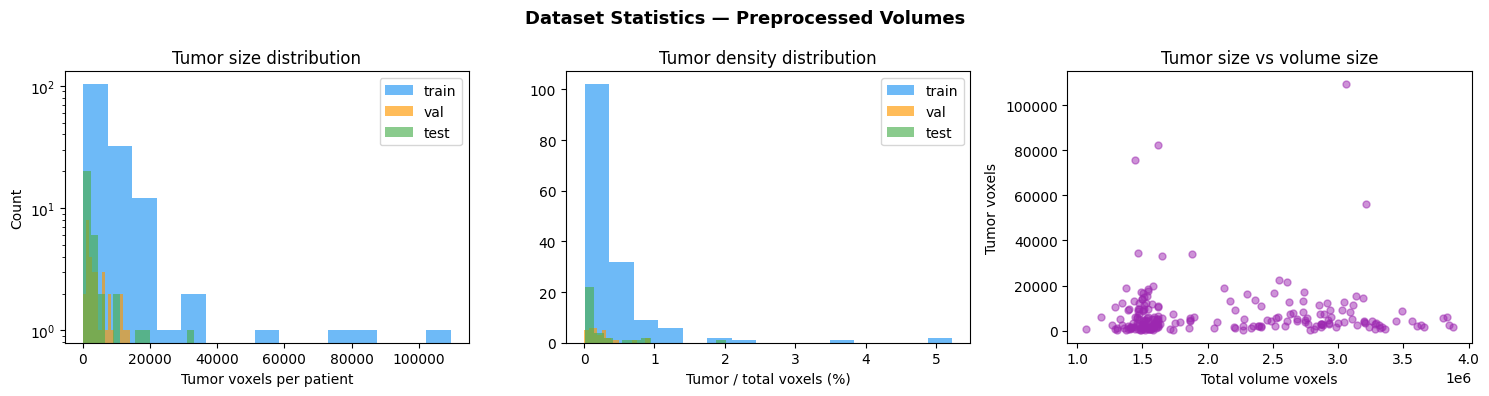

Saved: outputs/dataset_statistics.png


In [2]:
# ============================================================
# CELL 2 — Dataset inspection
# ============================================================
def inspect_split(split_name):
    data_list = _build_data_list(PREPROCESSED_ROOT, split_name)
    shapes, tumor_voxels, total_voxels, ratios = [], [], [], []
    for entry in data_list:
        img   = np.load(entry['image'])
        lbl   = np.load(entry['label'])
        shapes.append(img.shape)
        tv = int((lbl > 0).sum())
        tot = lbl.size
        tumor_voxels.append(tv)
        total_voxels.append(tot)
        ratios.append(tv / tot * 100)
    return data_list, shapes, tumor_voxels, ratios

print('Loading dataset statistics (reads all .npy files)...')
splits = {}
for spl in ['train', 'val', 'test']:
    dl, sh, tv, rt = inspect_split(spl)
    splits[spl] = {'data': dl, 'shapes': sh, 'tumor_voxels': tv, 'ratios': rt}
    D = [s[1] for s in sh]; H = [s[2] for s in sh]; W = [s[3] for s in sh]
    if len(dl) == 0:
        print(f'\n  {spl.upper()} (0 patients) — check PREPROCESSED_ROOT path!')
        continue
    print(f'\n  {spl.upper()} ({len(dl)} patients)')
    print(f'    Volume D : {min(D)}–{max(D)}  H : {min(H)}–{max(H)}  W : {min(W)}–{max(W)}')
    print(f'    Tumor voxels : {min(tv):,} – {max(tv):,}  (mean {np.mean(tv):.0f})')
    print(f'    Tumor ratio  : {min(rt):.4f}% – {max(rt):.4f}%  (mean {np.mean(rt):.4f}%)')

# ---- Dataset stats plot ----
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('Dataset Statistics — Preprocessed Volumes', fontsize=13, fontweight='bold')

colors = {'train': '#2196F3', 'val': '#FF9800', 'test': '#4CAF50'}

# Tumor voxel distribution
ax = axes[0]
for spl, c in colors.items():
    ax.hist(splits[spl]['tumor_voxels'], bins=15, alpha=0.65, color=c, label=spl)
ax.set_xlabel('Tumor voxels per patient')
ax.set_ylabel('Count')
ax.set_title('Tumor size distribution')
ax.legend()
ax.set_yscale('log')

# Tumor ratio
ax = axes[1]
for spl, c in colors.items():
    ax.hist(splits[spl]['ratios'], bins=15, alpha=0.65, color=c, label=spl)
ax.set_xlabel('Tumor / total voxels (%)')
ax.set_title('Tumor density distribution')
ax.legend()

# Volume sizes
ax = axes[2]
all_tv = splits['train']['tumor_voxels'] + splits['val']['tumor_voxels'] + splits['test']['tumor_voxels']
all_sh = splits['train']['shapes'] + splits['val']['shapes'] + splits['test']['shapes']
vols   = [s[1]*s[2]*s[3] for s in all_sh]
ax.scatter(vols, all_tv, alpha=0.5, color='#9C27B0', s=25)
ax.set_xlabel('Total volume voxels')
ax.set_ylabel('Tumor voxels')
ax.set_title('Tumor size vs volume size')

plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'dataset_statistics.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Saved: outputs/dataset_statistics.png')


--- Small tumor (voxels: 941) ---


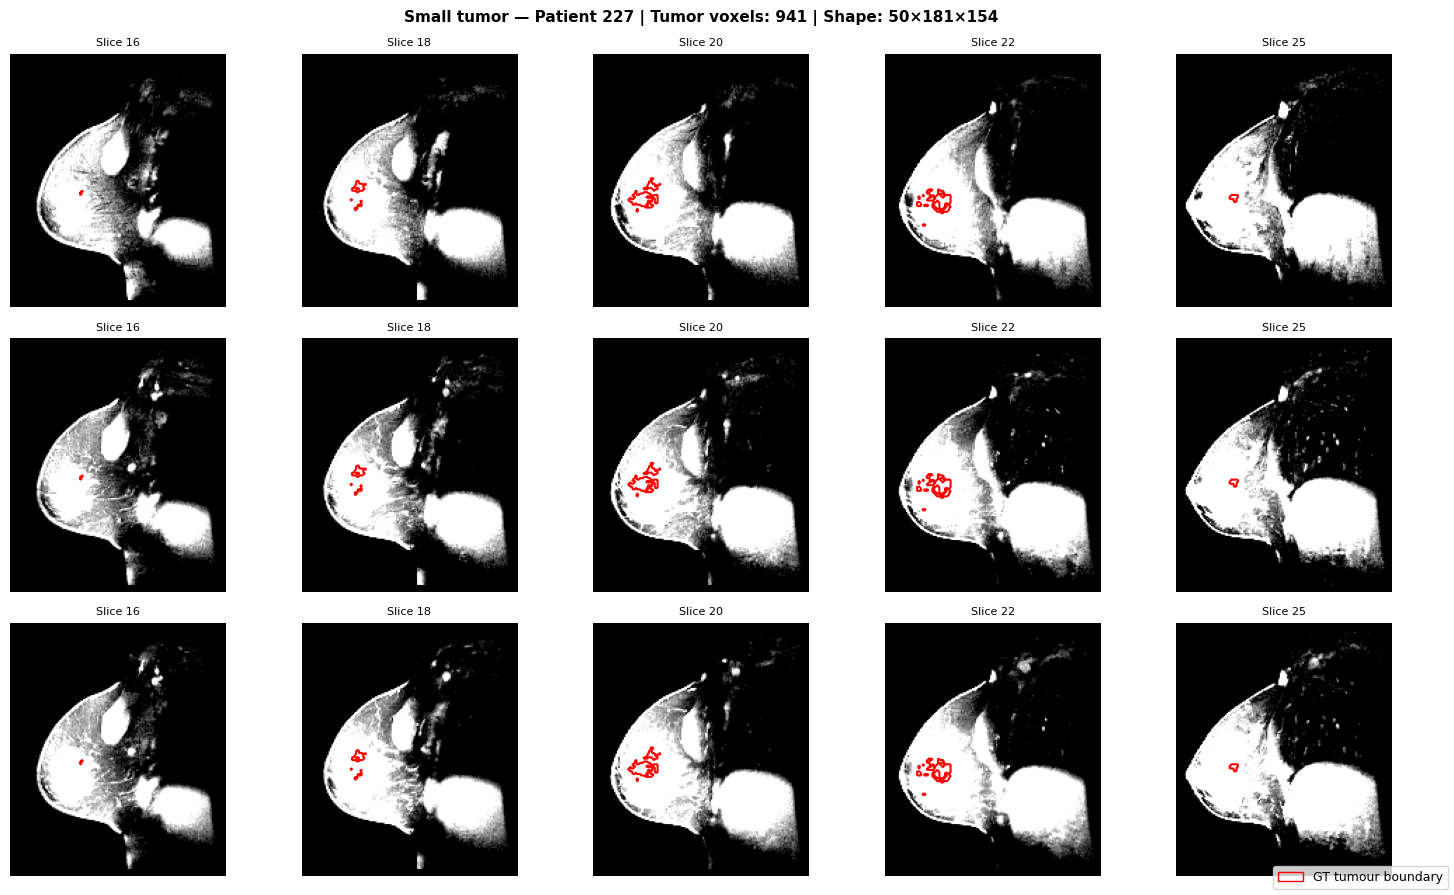


--- Median tumor (voxels: 4,487) ---


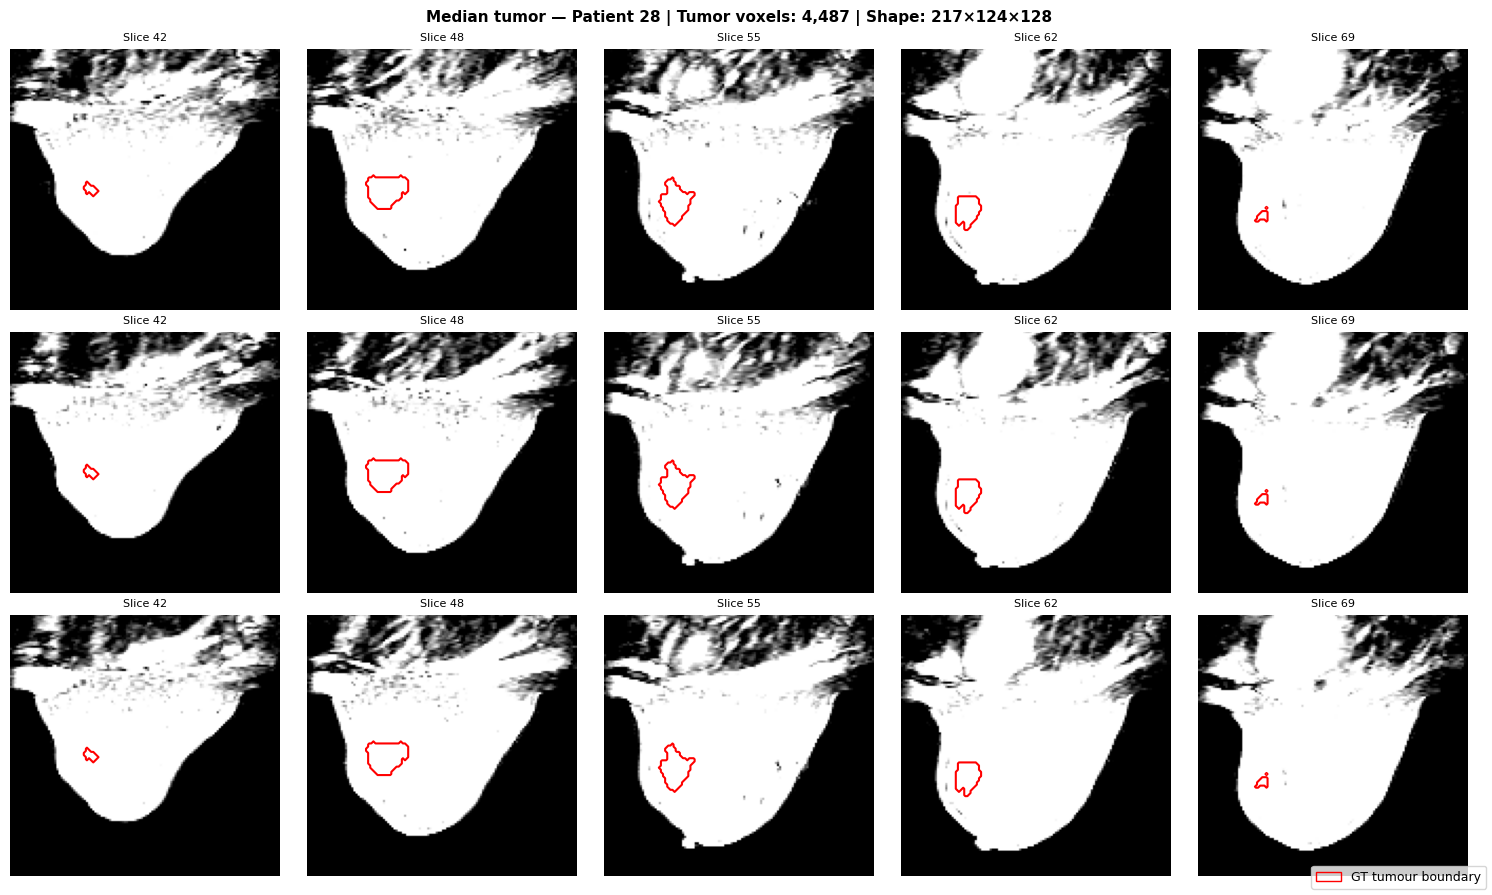


--- Large tumor (voxels: 16,700) ---


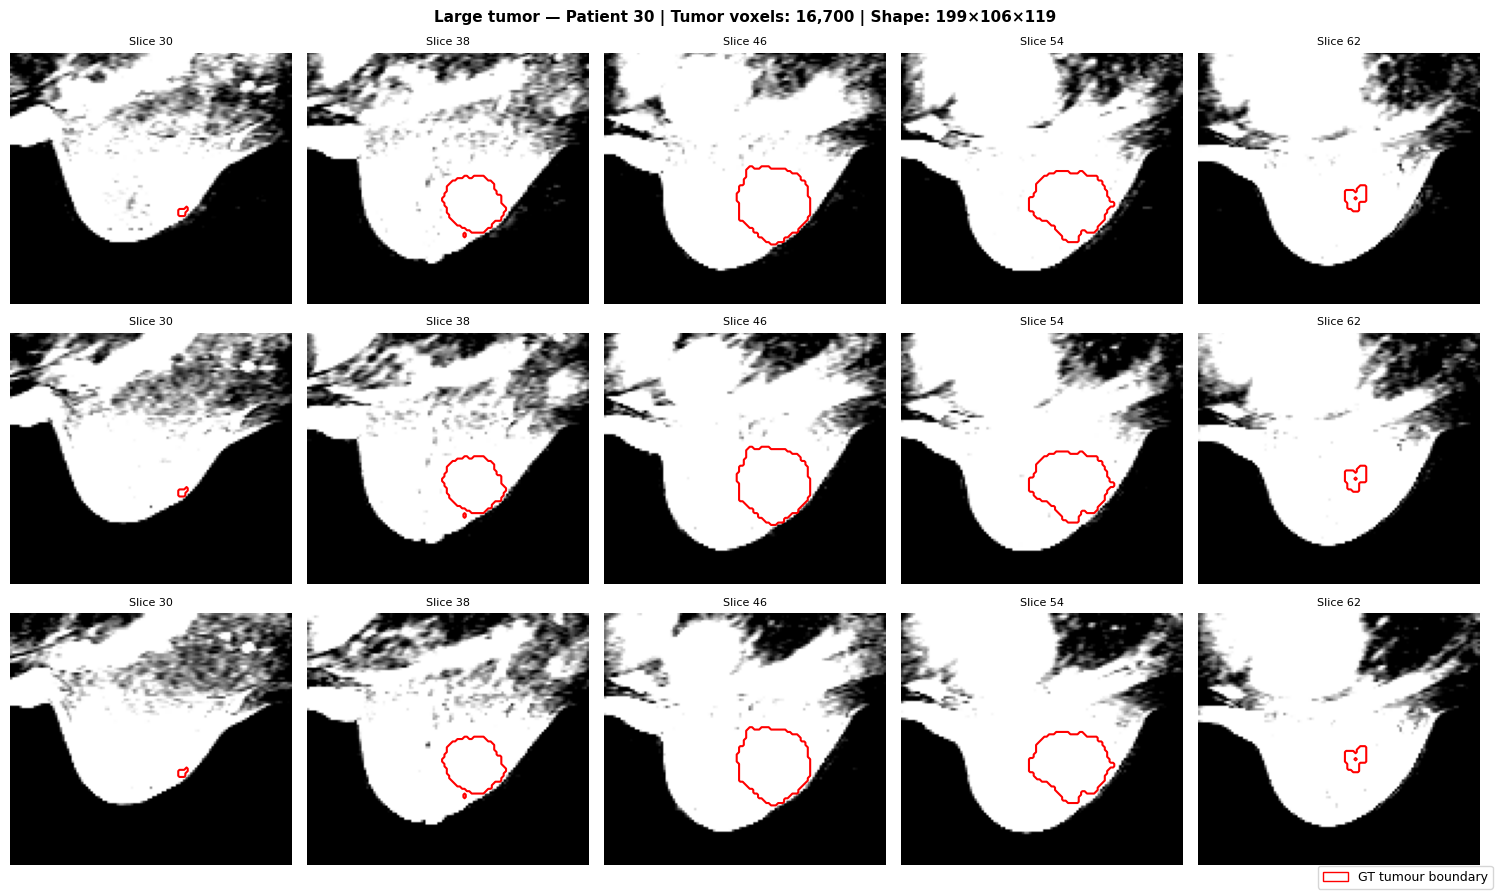

In [3]:
# ============================================================
# CELL 3 — Visualise raw preprocessed volumes
# Shows 3 representative patients: small, medium, large tumor
# ============================================================
def show_volume_slices(patient_entry, title='', n_slices=5):
    """Show axial slices through the volume with GT mask overlay."""
    img = np.load(patient_entry['image'])  # (3, D, H, W)
    lbl = np.load(patient_entry['label'])  # (1, D, H, W)
    pid = patient_entry['patient_id']

    # Find slices containing tumor
    lbl_sq = lbl.squeeze()  # (D, H, W)
    tumor_slices = np.where(lbl_sq.sum(axis=(1,2)) > 0)[0]

    if len(tumor_slices) == 0:
        print(f'  Patient {pid}: no tumor voxels found in label')
        return

    # Pick evenly-spaced slices through tumor region
    indices = np.linspace(tumor_slices[0], tumor_slices[-1], n_slices, dtype=int)

    fig, axes = plt.subplots(3, n_slices, figsize=(n_slices * 3, 9))
    fig.suptitle(f'{title} — Patient {pid} | '
                 f'Tumor voxels: {int((lbl>0).sum()):,} | '
                 f'Shape: {img.shape[1]}×{img.shape[2]}×{img.shape[3]}',
                 fontsize=11, fontweight='bold')

    channel_names = ['P1 (early)', 'P2 (mid)', 'P3 (late)']

    for col, sl in enumerate(indices):
        for row in range(3):
            ax = axes[row, col]
            slice_img = img[row, sl, :, :]  # H × W
            ax.imshow(slice_img, cmap='gray', vmin=0, vmax=1)

            # GT mask overlay in red
            mask_sl = lbl_sq[sl, :, :]
            if mask_sl.sum() > 0:
                ax.contour(mask_sl, levels=[0.5], colors='red', linewidths=1.5)

            if col == 0:
                ax.set_ylabel(channel_names[row], fontsize=9)
            ax.set_title(f'Slice {sl}', fontsize=8)
            ax.axis('off')

    # Legend
    patch = mpatches.Patch(edgecolor='red', facecolor='none', label='GT tumour boundary')
    fig.legend(handles=[patch], loc='lower right', fontsize=9)
    plt.tight_layout()
    plt.savefig(f'outputs/patient_{pid}_slices.png', dpi=100, bbox_inches='tight')
    plt.show()

# Pick patients with small, median, large tumors from train set
if 'train' not in splits or len(splits['train']['data']) == 0:
    print('Train split empty — check PREPROCESSED_ROOT in Cell 1.')
else:
    train_list = splits['train']['data']
    tvs        = splits['train']['tumor_voxels']
    sorted_idx = np.argsort(tvs)
    n          = len(sorted_idx)

    small_idx  = sorted_idx[max(0, n//10)]
    median_idx = sorted_idx[n//2]
    large_idx  = sorted_idx[min(n-1, int(n*0.9))]

    for idx, label in [(small_idx, 'Small tumor'), (median_idx, 'Median tumor'), (large_idx, 'Large tumor')]:
        print(f'\n--- {label} (voxels: {tvs[idx]:,}) ---')
        show_volume_slices(train_list[idx], title=label)

In [4]:
# ============================================================
# CELL 4 — Model definition + parameter count
# ============================================================
import math
from model_3d import get_model, MODEL_CONFIG

model = get_model(device)

# Compute OUTPUT_BIAS_INIT from prevalence (same formula as model_3d.py)
TUMOR_PREVALENCE = 0.0005
OUTPUT_BIAS_INIT = math.log(TUMOR_PREVALENCE / (1.0 - TUMOR_PREVALENCE))   # ≈ -7.60

# Parameter count by layer group
layer_params = {}
for name, param in model.named_parameters():
    group = name.split('.')[0]
    layer_params[group] = layer_params.get(group, 0) + param.numel()

total = sum(p.numel() for p in model.parameters())

print('\n  Architecture summary:')
print(f'    Spatial dims   : {MODEL_CONFIG["spatial_dims"]}D')
print(f'    Input channels : {MODEL_CONFIG["in_channels"]} (P1, P2, P3)')
print(f'    Encoder depth  : {MODEL_CONFIG["channels"]}')
print(f'    Norm           : {MODEL_CONFIG["norm"]}')
print(f'    Output bias    : {OUTPUT_BIAS_INIT:.4f}  (sigmoid={math.exp(OUTPUT_BIAS_INIT)/(1+math.exp(OUTPUT_BIAS_INIT)):.5f})')
print(f'    Total params   : {total:,}')
print(f'    Precision      : BF16 mixed (torch.amp)')

# VRAM estimate
from data_3d import PATCH_SIZE   # import here so all later cells have it
patch = PATCH_SIZE
batch = 2 if is_3050 else 4
patch_vox = patch[0] * patch[1] * patch[2]
input_mb  = batch * 3 * patch_vox * 2 / 1e6
weight_mb = total * 4 / 1e6
print(f'\n  VRAM estimate (batch {batch}, patch {patch[0]}³, BF16):')
print(f'    Input tensor   : ~{input_mb:.0f} MB')
print(f'    Weights (fp32) : ~{weight_mb:.0f} MB')
print(f'    Should fit on  : {vram_gb:.1f} GB GPU')


  Output bias layer : model.2.1.conv.unit0.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumor prevalence)
Model : MONAI ResNet UNet 3D
  spatial_dims  : 3
  in_channels   : 3  (P1, P2, P3)
  channels      : (32, 64, 128, 256, 320)
  strides       : (2, 2, 2, 2)
  num_res_units : 2
  norm          : instance
  dropout       : 0.1
  Total params  : 12,865,085
  Trainable     : 12,865,085
  Device        : cuda

  Architecture summary:
    Spatial dims   : 3D
    Input channels : 3 (P1, P2, P3)
    Encoder depth  : (32, 64, 128, 256, 320)
    Norm           : instance
    Output bias    : -7.6004  (sigmoid=0.00050)
    Total params   : 12,865,085
    Precision      : BF16 mixed (torch.amp)

  VRAM estimate (batch 4, patch 96³, BF16):
    Input tensor   : ~21 MB
    Weights (fp32) : ~51 MB
    Should fit on  : 17.2 GB GPU


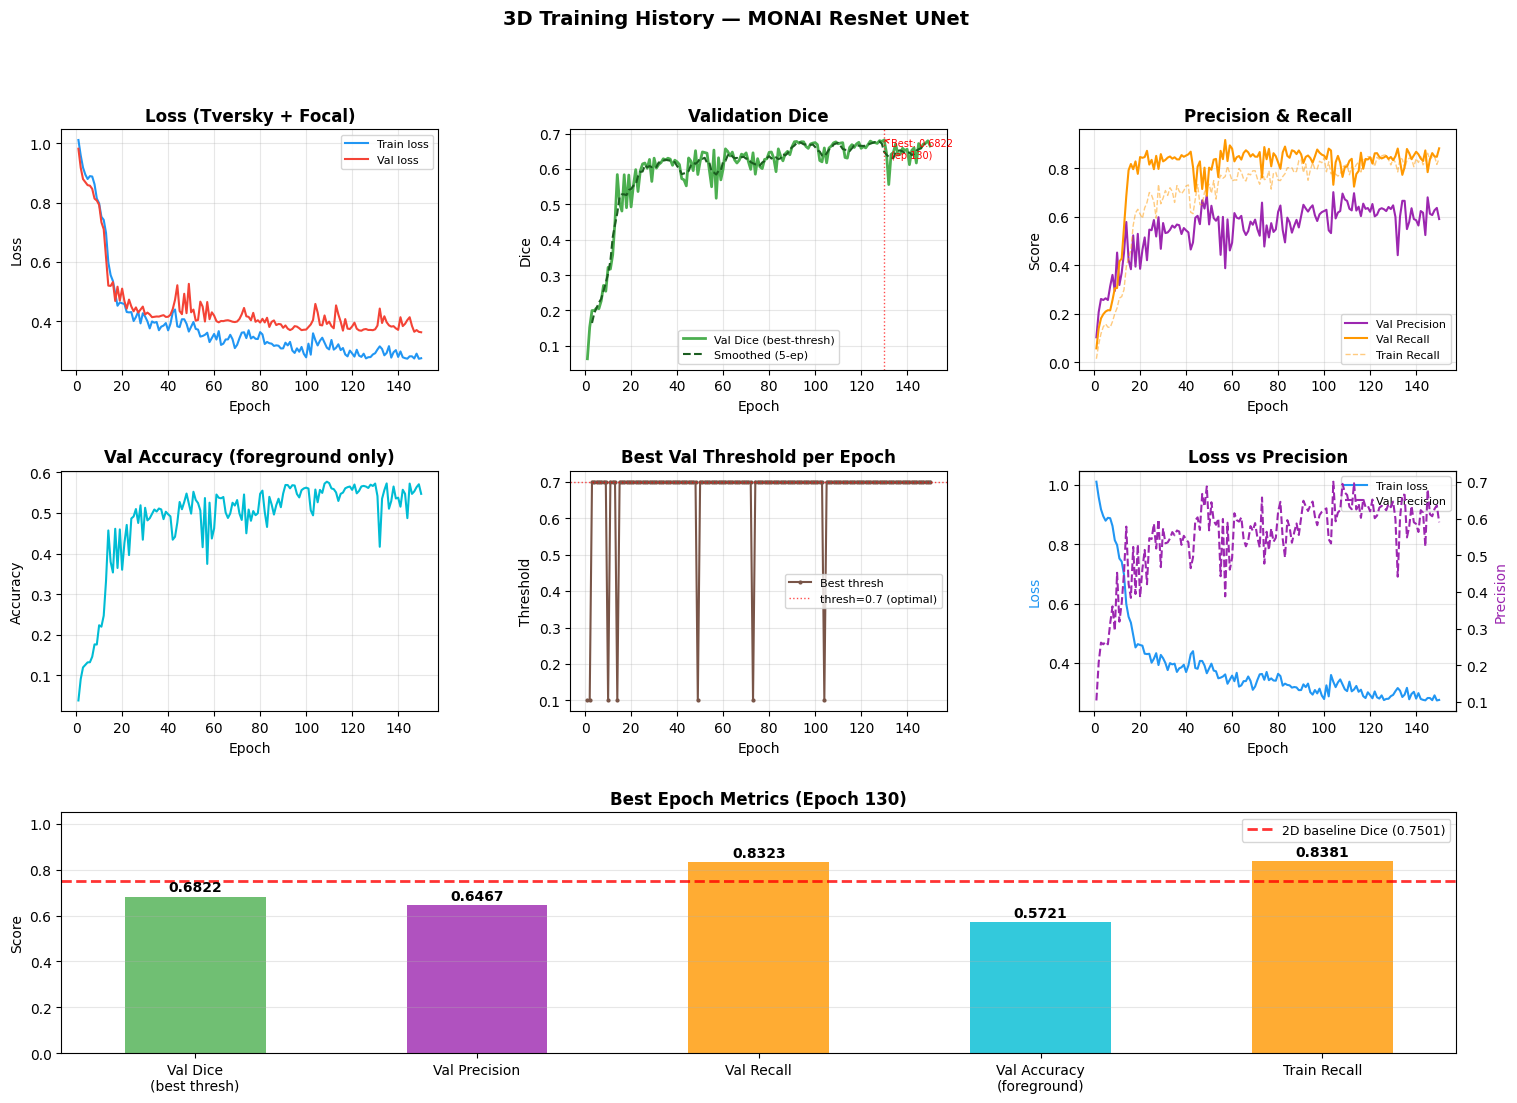

Saved: outputs/training_curves_3d.png

Best val Dice  : 0.6822 at epoch 130
Final val loss : 0.3633


In [5]:
# ============================================================
# CELL 6 — Training curves
# Loads training_history_3d.npy and plots all metrics
# ============================================================
if not os.path.exists(HISTORY_FILE):
    print(f'History file not found: {HISTORY_FILE}')
    print('Run Cell 5 (training) first.')
else:
    history = np.load(HISTORY_FILE, allow_pickle=True).item()

    epochs_done = len(history['val_dice'])
    ep = np.arange(1, epochs_done + 1)

    fig = plt.figure(figsize=(18, 12))
    fig.suptitle('3D Training History — MONAI ResNet UNet', fontsize=14, fontweight='bold')
    gs = GridSpec(3, 3, figure=fig, hspace=0.42, wspace=0.35)

    # --- 1. Loss ---
    ax1 = fig.add_subplot(gs[0, 0])
    ax1.plot(ep, history['train_loss'], color='#2196F3', lw=1.5, label='Train loss')
    ax1.plot(ep, history['val_loss'],   color='#F44336', lw=1.5, label='Val loss')
    ax1.set_title('Loss (Tversky + Focal)', fontweight='bold')
    ax1.set_xlabel('Epoch'); ax1.set_ylabel('Loss')
    ax1.legend(fontsize=8); ax1.grid(alpha=0.3)

    # --- 2. Val Dice ---
    ax2 = fig.add_subplot(gs[0, 1])
    ax2.plot(ep, history['val_dice'], color='#4CAF50', lw=2, label='Val Dice (best-thresh)')
    # smoothed Dice
    smooth = np.convolve(history['val_dice'], np.ones(5)/5, mode='valid')
    ax2.plot(np.arange(3, 3+len(smooth)), smooth, color='#1B5E20', lw=1.5,
             linestyle='--', label='Smoothed (5-ep)')
    best_ep = int(np.argmax(history['val_dice'])) + 1
    best_d  = max(history['val_dice'])
    ax2.axvline(best_ep, color='red', lw=1, linestyle=':', alpha=0.7)
    ax2.annotate(f'Best: {best_d:.4f}\n(ep {best_ep})',
                 xy=(best_ep, best_d), xytext=(best_ep+3, best_d-0.05),
                 fontsize=7, color='red',
                 arrowprops=dict(arrowstyle='->', color='red', lw=0.8))
    ax2.set_title('Validation Dice', fontweight='bold')
    ax2.set_xlabel('Epoch'); ax2.set_ylabel('Dice')
    ax2.legend(fontsize=8); ax2.grid(alpha=0.3)

    # --- 3. Precision & Recall ---
    ax3 = fig.add_subplot(gs[0, 2])
    ax3.plot(ep, history['val_precision'], color='#9C27B0', lw=1.5, label='Val Precision')
    ax3.plot(ep, history['val_recall'],    color='#FF9800', lw=1.5, label='Val Recall')
    ax3.plot(ep, history['train_recall'],  color='#FF9800', lw=1,
             linestyle='--', alpha=0.5, label='Train Recall')
    ax3.set_title('Precision & Recall', fontweight='bold')
    ax3.set_xlabel('Epoch'); ax3.set_ylabel('Score')
    ax3.legend(fontsize=8); ax3.grid(alpha=0.3)

    # --- 4. Val Accuracy ---
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(ep, history['val_accuracy'], color='#00BCD4', lw=1.5)
    ax4.set_title('Val Accuracy (foreground only)', fontweight='bold')
    ax4.set_xlabel('Epoch'); ax4.set_ylabel('Accuracy')
    ax4.grid(alpha=0.3)

    # --- 5. Best threshold per epoch ---
    ax5 = fig.add_subplot(gs[1, 1])
    if 'val_best_thresh' in history:
        ax5.plot(ep, history['val_best_thresh'], color='#795548', lw=1.5,
                 marker='o', markersize=2, label='Best thresh')
        ax5.axhline(y=0.7, color='red', lw=1, linestyle=':', alpha=0.7, label='thresh=0.7 (optimal)')
        ax5.set_title('Best Val Threshold per Epoch', fontweight='bold')
        ax5.set_xlabel('Epoch'); ax5.set_ylabel('Threshold')
        ax5.legend(fontsize=8); ax5.grid(alpha=0.3)
    else:
        ax5.text(0.5, 0.5, 'Threshold history\nnot available\n(older training run)',
                 ha='center', va='center', transform=ax5.transAxes)

    # --- 6. Train loss + Precision together ---
    ax6 = fig.add_subplot(gs[1, 2])
    ax6_r = ax6.twinx()
    ax6.plot(ep, history['train_loss'], color='#2196F3', lw=1.5, label='Train loss')
    ax6_r.plot(ep, history['val_precision'], color='#9C27B0', lw=1.5,
               linestyle='--', label='Val Precision')
    ax6.set_title('Loss vs Precision', fontweight='bold')
    ax6.set_xlabel('Epoch')
    ax6.set_ylabel('Loss', color='#2196F3')
    ax6_r.set_ylabel('Precision', color='#9C27B0')
    lines1, labels1 = ax6.get_legend_handles_labels()
    lines2, labels2 = ax6_r.get_legend_handles_labels()
    ax6.legend(lines1+lines2, labels1+labels2, fontsize=8)
    ax6.grid(alpha=0.3)

    # --- 7. Summary bar chart ---
    ax7 = fig.add_subplot(gs[2, :])
    metrics_labels = ['Val Dice\n(best thresh)', 'Val Precision', 'Val Recall',
                      'Val Accuracy\n(foreground)', 'Train Recall']
    best_epoch_idx = int(np.argmax(history['val_dice']))
    metric_vals = [
        history['val_dice'][best_epoch_idx],
        history['val_precision'][best_epoch_idx],
        history['val_recall'][best_epoch_idx],
        history['val_accuracy'][best_epoch_idx],
        history['train_recall'][best_epoch_idx],
    ]
    bar_colors = ['#4CAF50', '#9C27B0', '#FF9800', '#00BCD4', '#FF9800']
    bars = ax7.bar(metrics_labels, metric_vals, color=bar_colors, alpha=0.8, width=0.5)
    for bar, val in zip(bars, metric_vals):
        ax7.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
    # 2D baseline reference
    ax7.axhline(y=0.7501, color='red', lw=2, linestyle='--', alpha=0.8, label='2D baseline Dice (0.7501)')
    ax7.set_title(f'Best Epoch Metrics (Epoch {best_epoch_idx+1})', fontweight='bold')
    ax7.set_ylabel('Score')
    ax7.set_ylim(0, 1.05)
    ax7.legend(fontsize=9)
    ax7.grid(axis='y', alpha=0.3)

    plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'training_curves_3d.png'), dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Saved: outputs/training_curves_3d.png')
    print(f'\nBest val Dice  : {best_d:.4f} at epoch {best_ep}')
    print(f'Final val loss : {history["val_loss"][-1]:.4f}')

  Output bias layer : model.2.1.conv.unit0.conv.bias
  Output bias init  : -7.6004  (sigmoid = 0.00050  ≈ tumor prevalence)
Model : MONAI ResNet UNet 3D
  spatial_dims  : 3
  in_channels   : 3  (P1, P2, P3)
  channels      : (32, 64, 128, 256, 320)
  strides       : (2, 2, 2, 2)
  num_res_units : 2
  norm          : instance
  dropout       : 0.1
  Total params  : 12,865,085
  Trainable     : 12,865,085
  Device        : cuda
Model loaded: E:\Breast_Tumor_AI_Project\models\segmentation_3d\unet3d_best.pth
  [Dataset:val] old=15  new=17  total=32

Sweeping 9 thresholds on 32 val patients...

  Threshold sweep results:
     Threshold |  Mean Dice
  -------------+-----------
          0.05 |     0.6198
          0.10 |     0.6343
          0.20 |     0.6478
          0.30 |     0.6550
          0.40 |     0.6598
          0.50 |     0.6642
          0.60 |     0.6679
          0.70 |     0.6709
          0.80 |     0.6735 ← BEST

  Optimal threshold : 0.8
  Set THRESHOLD = 0.8 in predict_3

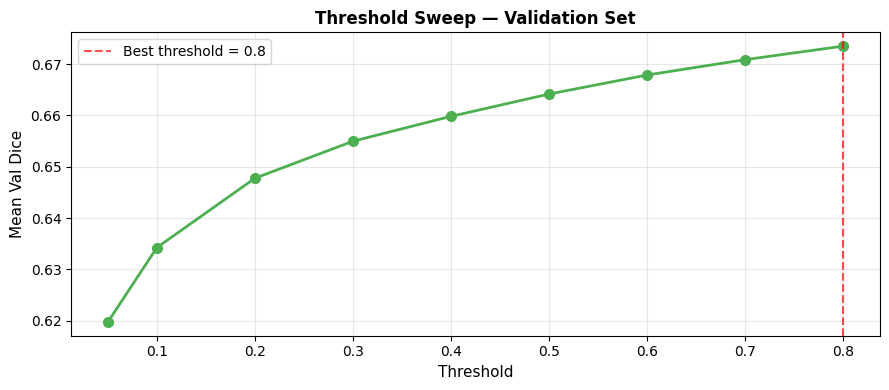


BEST_THRESHOLD set to: 0.8


In [7]:
# ============================================================
# CELL 7 — Threshold sweep on validation set
# Finds the best global threshold for predict_3d.py
# ============================================================
from data_3d import NpyDataset, get_val_transforms, PATCH_SIZE, _build_data_list
from torch.utils.data import DataLoader
from monai.inferers import sliding_window_inference
from torch.amp import autocast

MODEL_PATH = os.path.join(MODEL_DIR, 'unet3d_best.pth')

assert os.path.exists(MODEL_PATH), f'Model not found: {MODEL_PATH}. Run training first.'

# Reload model with trained weights
model = get_model(device)
model.load_state_dict(torch.load(MODEL_PATH, map_location=device, weights_only=True))
model.eval()
print(f'Model loaded: {MODEL_PATH}')

THRESHOLDS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]

val_list   = _build_data_list(PREPROCESSED_ROOT, 'val')
val_ds     = NpyDataset(val_list, transform=get_val_transforms())
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

def compute_dice_np(p, g):
    return 2 * np.logical_and(p,g).sum() / (p.sum() + g.sum() + 1e-8)

print(f'\nSweeping {len(THRESHOLDS)} thresholds on {len(val_list)} val patients...')

thresh_dices = {t: [] for t in THRESHOLDS}

with torch.no_grad():
    for batch in val_loader:
        images = batch['image'].to(device)
        labels = batch['label']
        gt_np  = (labels.squeeze().numpy() > 0).astype(bool)
        if gt_np.sum() == 0:
            continue

        with autocast('cuda', dtype=torch.bfloat16):
            logits = sliding_window_inference(
                inputs=images, roi_size=PATCH_SIZE,
                sw_batch_size=4, predictor=model,
                overlap=0.5, mode='gaussian')

        prob = torch.sigmoid(logits.float()).squeeze().cpu().numpy()

        for t in THRESHOLDS:
            pred = (prob > t).astype(bool)
            thresh_dices[t].append(compute_dice_np(pred, gt_np))

mean_dices = {t: np.mean(v) for t, v in thresh_dices.items()}
best_thresh = max(mean_dices, key=mean_dices.get)

print(f'\n  Threshold sweep results:')
print(f'  {"Threshold":>12} | {"Mean Dice":>10}')
print(f'  {"-"*12}-+-{"-"*10}')
for t, d in sorted(mean_dices.items()):
    marker = ' ← BEST' if t == best_thresh else ''
    print(f'  {t:>12.2f} | {d:>10.4f}{marker}')

print(f'\n  Optimal threshold : {best_thresh}')
print(f'  Set THRESHOLD = {best_thresh} in predict_3d.py')

# Plot
fig, ax = plt.subplots(figsize=(9, 4))
ts = sorted(mean_dices.keys())
ds = [mean_dices[t] for t in ts]
ax.plot(ts, ds, 'o-', color='#4CAF50', lw=2, markersize=7)
ax.axvline(best_thresh, color='red', lw=1.5, linestyle='--', alpha=0.7,
           label=f'Best threshold = {best_thresh}')
ax.set_xlabel('Threshold', fontsize=11)
ax.set_ylabel('Mean Val Dice', fontsize=11)
ax.set_title('Threshold Sweep — Validation Set', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'threshold_sweep.png'), dpi=120, bbox_inches='tight')
plt.show()

# Store for use in next cells
BEST_THRESHOLD = best_thresh
print(f'\nBEST_THRESHOLD set to: {BEST_THRESHOLD}')

In [8]:
# ============================================================
# CELL 8 — Inference on test set (sliding window + TTA)
# ============================================================
from scipy import ndimage
from tqdm.notebook import tqdm

# Use best threshold from Cell 7, or set manually
try:
    INFER_THRESHOLD = BEST_THRESHOLD
except NameError:
    INFER_THRESHOLD = 0.7  # default if Cell 7 wasn't run

TTA_ENABLED = True
SW_OVERLAP  = 0.5

print(f'Inference config:')
print(f'  Model     : {MODEL_PATH}')
print(f'  Threshold : {INFER_THRESHOLD}')
print(f'  TTA       : {"8 orientations" if TTA_ENABLED else "disabled"}')
print(f'  Patch     : {PATCH_SIZE}')

def predict_volume(image_tensor):
    with torch.no_grad():
        with autocast('cuda', dtype=torch.bfloat16):
            logits = sliding_window_inference(
                inputs=image_tensor, roi_size=PATCH_SIZE,
                sw_batch_size=4, predictor=model,
                overlap=SW_OVERLAP, mode='gaussian')
    return torch.sigmoid(logits.float()).squeeze().cpu().numpy().astype(np.float32)

def predict_with_tta(image_tensor):
    img_np   = image_tensor.squeeze(0).cpu().numpy()
    prob_sum = predict_volume(image_tensor)
    for axes in [(2,),(3,),(4,),(2,3),(2,4),(3,4),(2,3,4)]:
        flipped_np     = np.flip(img_np, axis=[a-1 for a in axes]).copy()
        flipped_t      = torch.tensor(flipped_np).unsqueeze(0).float().to(device)
        prob_flip      = predict_volume(flipped_t)
        prob_sum      += np.flip(prob_flip, axis=[a-2 for a in axes]).copy()
    return (prob_sum / 8).astype(np.float32)

def post_process(binary_mask, min_size_voxels=50):
    struct  = ndimage.generate_binary_structure(3, 1)
    closed  = ndimage.binary_closing(binary_mask, structure=struct, iterations=2)
    labeled, n = ndimage.label(closed)
    if n == 0:
        return closed.astype(np.uint8)
    cleaned = np.zeros_like(closed, dtype=np.uint8)
    for i in range(1, n+1):
        if (labeled == i).sum() >= min_size_voxels:
            cleaned[labeled == i] = 1
    return cleaned

test_list   = _build_data_list(PREPROCESSED_ROOT, 'test')
test_ds     = NpyDataset(test_list, transform=get_val_transforms())
test_loader = DataLoader(test_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=False)

results = []
prob_maps_cache = []  # cache for visualisation in next cell

for idx, batch in enumerate(tqdm(test_loader, desc='Inference')):
    images     = batch['image'].to(device)
    labels     = batch['label']
    patient_id = test_list[idx]['patient_id']

    prob_map    = predict_with_tta(images) if TTA_ENABLED else predict_volume(images)
    binary_mask = post_process((prob_map > INFER_THRESHOLD).astype(np.uint8))

    gt_np   = (labels.squeeze().numpy() > 0).astype(bool)
    pred_np = binary_mask.astype(bool)
    inter   = np.logical_and(pred_np, gt_np).sum()
    dice    = float(2 * inter / (pred_np.sum() + gt_np.sum() + 1e-8))
    iou     = float(inter / (np.logical_or(pred_np, gt_np).sum() + 1e-8))

    results.append({'patient_id': patient_id, 'dice': dice, 'iou': iou,
                    'gt_voxels': int(gt_np.sum()), 'pred_voxels': int(pred_np.sum()),
                    'has_tumor': gt_np.sum() > 0, 'detected': pred_np.sum() > 0})

    # Cache image, GT, pred, prob for visualisation
    if idx < 15:  # cache all test patients
        prob_maps_cache.append({
            'patient_id': patient_id,
            'image': batch['image'].squeeze(0).numpy(),
            'gt':    gt_np,
            'pred':  pred_np,
            'prob':  prob_map,
            'dice':  dice
        })

    np.save(os.path.join(OUTPUT_DIR, f'patient{patient_id}_pred.npy'), binary_mask)
    np.save(os.path.join(OUTPUT_DIR, f'patient{patient_id}_prob.npy'), prob_map)

# Summary
tumor_dices = [r['dice'] for r in results if r['has_tumor']]
missed      = sum(1 for r in results if r['has_tumor'] and not r['detected'])
det_rate    = 100 * (1 - missed / len(tumor_dices)) if tumor_dices else 0

print(f'\n  Test set results (threshold={INFER_THRESHOLD}):')
print(f'  Patients       : {len(results)}')
print(f'  Tumor patients : {sum(r["has_tumor"] for r in results)}')
print(f'  Missed tumours : {missed}')
print(f'  Detection rate : {det_rate:.1f}%')
print(f'  Mean Dice      : {np.mean(tumor_dices):.4f}')
print(f'  Best Dice      : {np.max(tumor_dices):.4f}')
print(f'  Worst Dice     : {np.min(tumor_dices):.4f}')

Inference config:
  Model     : E:\Breast_Tumor_AI_Project\models\segmentation_3d\unet3d_best.pth
  Threshold : 0.8
  TTA       : 8 orientations
  Patch     : (96, 96, 96)
  [Dataset:test] old=15  new=18  total=33


Inference:   0%|          | 0/33 [00:00<?, ?it/s]


  Test set results (threshold=0.8):
  Patients       : 33
  Tumor patients : 33
  Missed tumours : 1
  Detection rate : 97.0%
  Mean Dice      : 0.6482
  Best Dice      : 0.9387
  Worst Dice     : 0.0000



--- Best prediction (Dice = 0.9387) ---


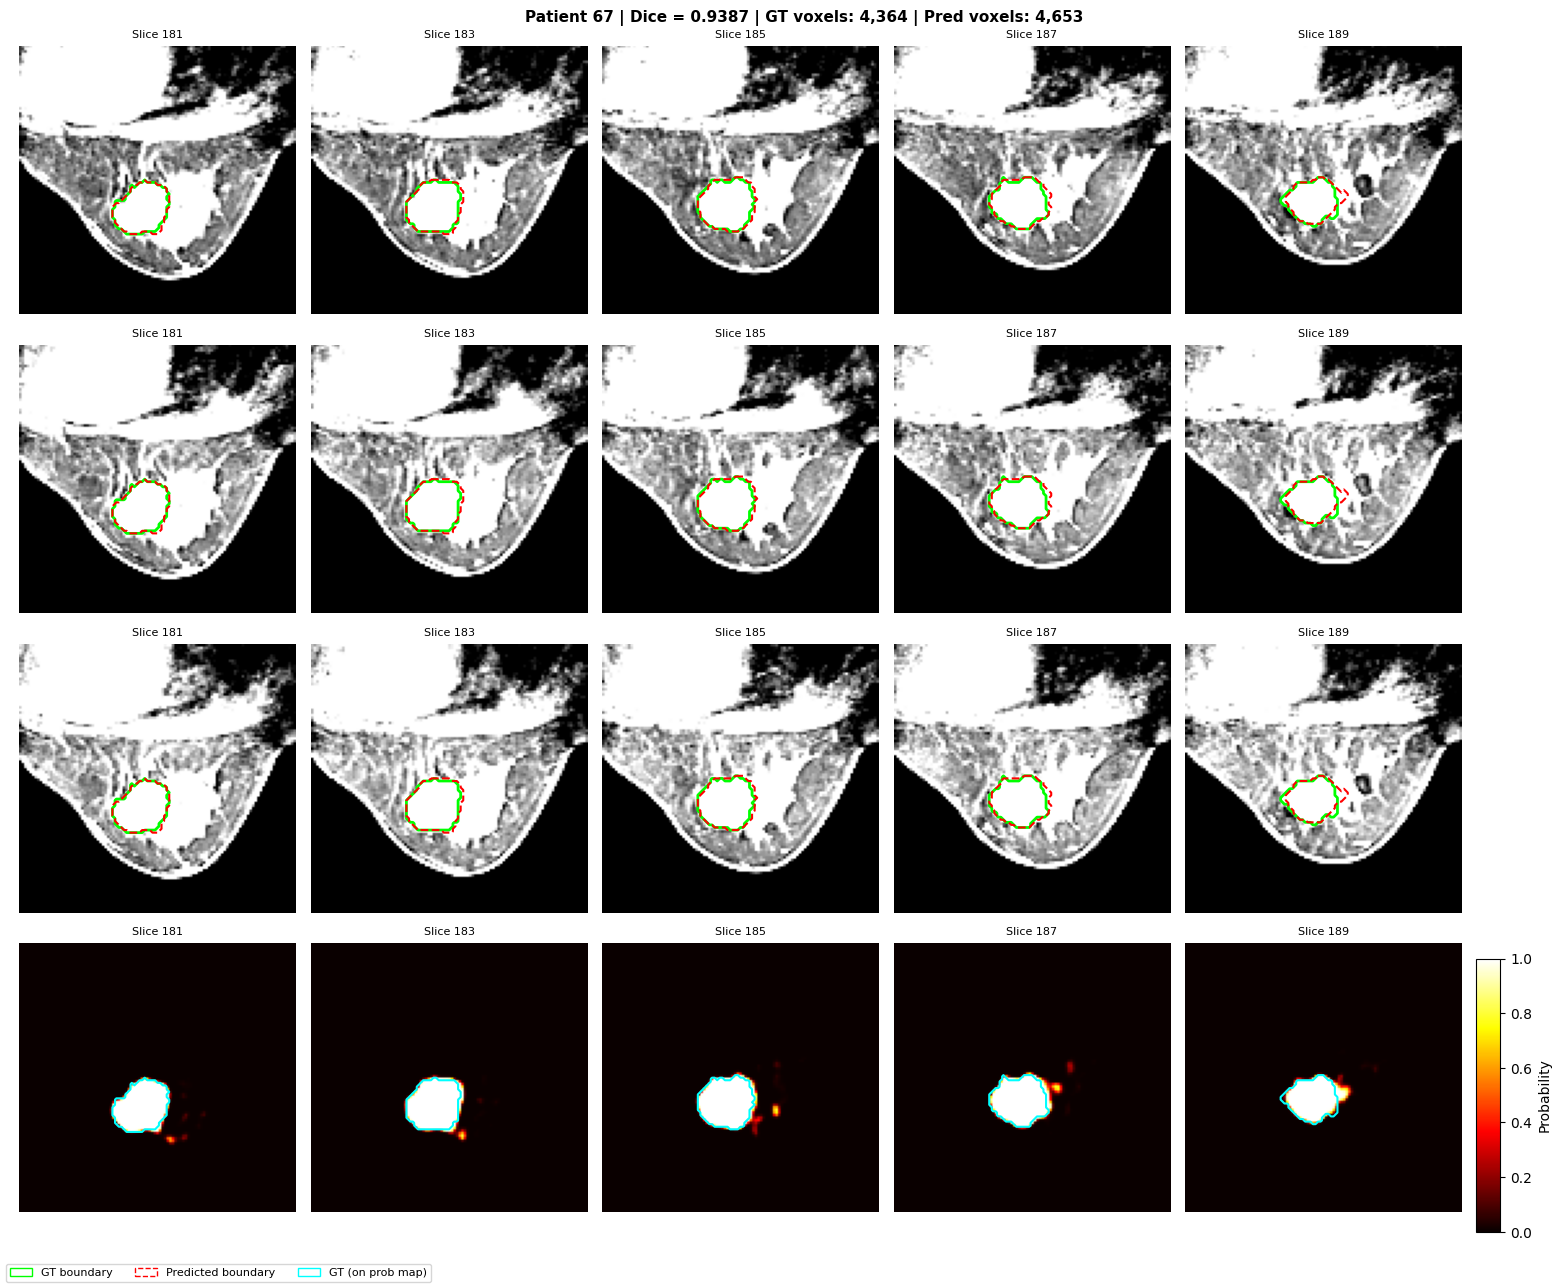

Saved: outputs/patient67_best.png

--- Median prediction (Dice = 0.8113) ---


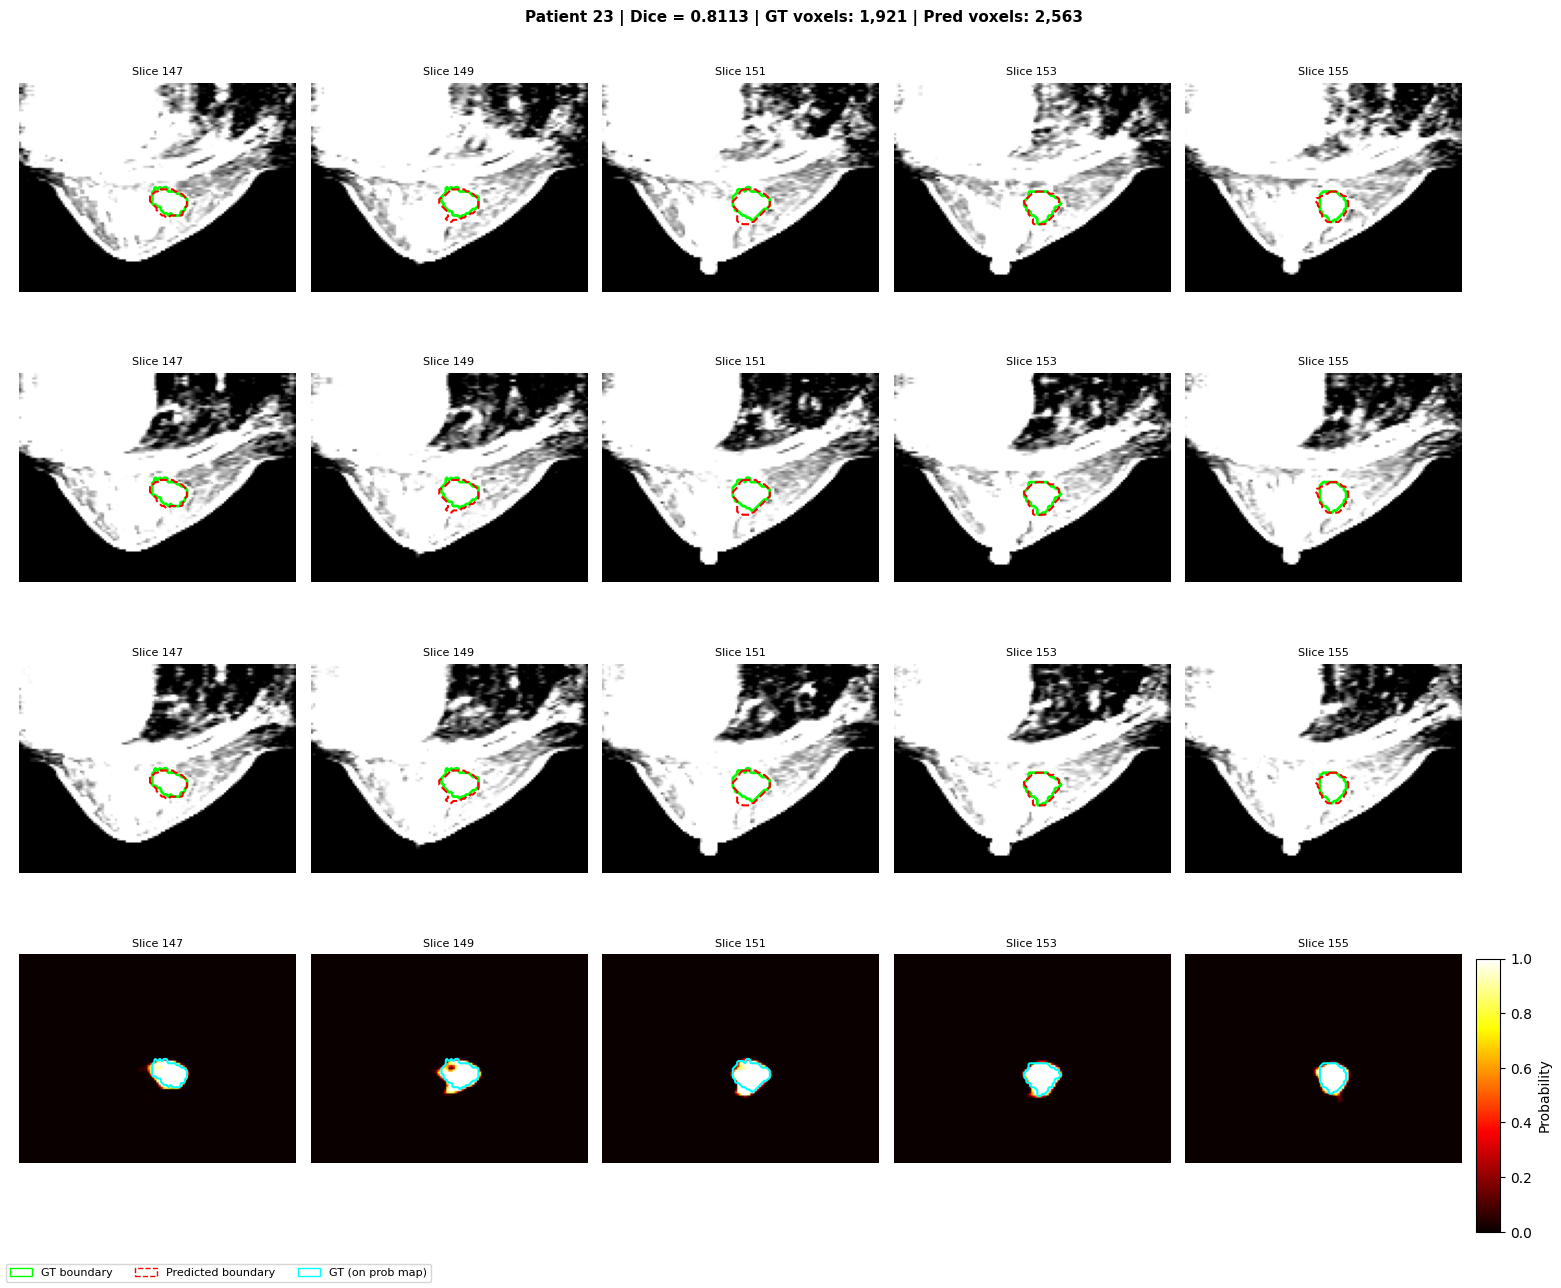

Saved: outputs/patient23_median.png

--- Worst prediction (Dice = 0.1202) ---


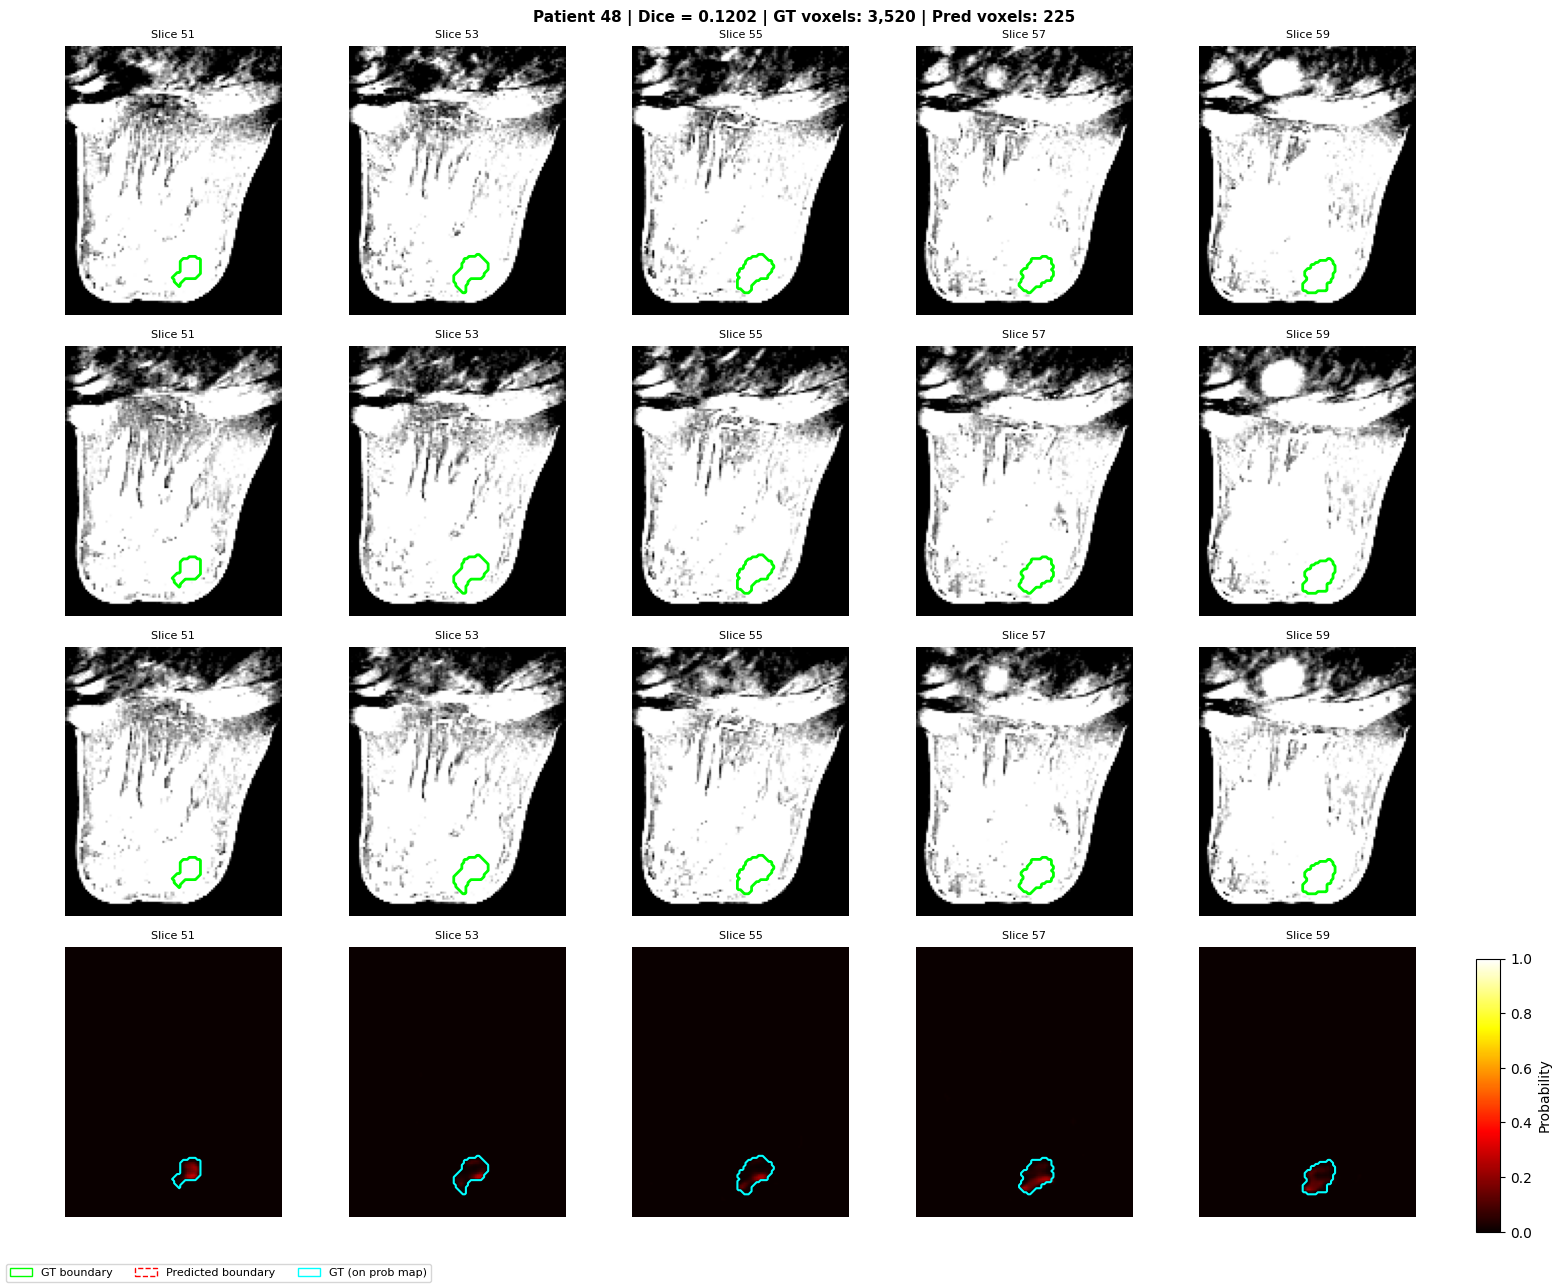

Saved: outputs/patient48_worst.png


In [13]:
# ============================================================
# CELL 9 — GT mask vs predicted mask overlay visualisation
# Shows 3 rows per patient: P1/P2/P3 with GT and prediction
# ============================================================

def visualise_prediction(cache_entry, save_path=None):
    pid    = cache_entry['patient_id']
    image  = cache_entry['image']   # (3, D, H, W)
    gt     = cache_entry['gt']      # (D, H, W) bool
    pred   = cache_entry['pred']    # (D, H, W) bool
    prob   = cache_entry['prob']    # (D, H, W) float
    dice   = cache_entry['dice']

    # Find best slice to show (most tumor content in GT)
    gt_per_slice   = gt.sum(axis=(1, 2))
    pred_per_slice = pred.sum(axis=(1, 2))

    if gt_per_slice.max() > 0:
        best_sl = int(np.argmax(gt_per_slice))
    else:
        best_sl = image.shape[1] // 2

    # Show 5 slices around best
    D = image.shape[1]
    slices = [max(0, best_sl - 4), max(0, best_sl - 2), best_sl,
              min(D-1, best_sl + 2), min(D-1, best_sl + 4)]
    slices = list(dict.fromkeys(slices))  # remove dupes

    n_sl   = len(slices)
    fig, axes = plt.subplots(4, n_sl, figsize=(n_sl * 3.2, 13))
    fig.suptitle(
        f'Patient {pid} | Dice = {dice:.4f} | '
        f'GT voxels: {int(gt.sum()):,} | Pred voxels: {int(pred.sum()):,}',
        fontsize=11, fontweight='bold'
    )

    row_titles = ['P1 (early phase)', 'P2 (mid phase)', 'P3 (late phase)', 'Probability map']

    for col, sl in enumerate(slices):
        for row in range(4):
            ax = axes[row, col]

            if row < 3:
                # MRI channel
                ax.imshow(image[row, sl], cmap='gray', vmin=0, vmax=1)
                # GT boundary — green
                if gt[sl].sum() > 0:
                    ax.contour(gt[sl].astype(float), levels=[0.5],
                               colors='lime', linewidths=2, linestyles='-')
                # Predicted boundary — red
                if pred[sl].sum() > 0:
                    ax.contour(pred[sl].astype(float), levels=[0.5],
                               colors='red', linewidths=1.5, linestyles='--')
            else:
                # Probability map
                im = ax.imshow(prob[sl], cmap='hot', vmin=0, vmax=1)
                if gt[sl].sum() > 0:
                    ax.contour(gt[sl].astype(float), levels=[0.5],
                               colors='cyan', linewidths=1.5)

            if col == 0:
                ax.set_ylabel(row_titles[row], fontsize=8)
            ax.set_title(f'Slice {sl}', fontsize=8)
            ax.axis('off')

    # Colorbar for probability row
    cbar_ax = fig.add_axes([0.92, 0.04, 0.015, 0.21])
    sm = plt.cm.ScalarMappable(cmap='hot', norm=plt.Normalize(0, 1))
    fig.colorbar(sm, cax=cbar_ax, label='Probability')

    # Legend
    patches = [
        mpatches.Patch(edgecolor='lime',  facecolor='none', label='GT boundary'),
        mpatches.Patch(edgecolor='red',   facecolor='none', label='Predicted boundary', linestyle='--'),
        mpatches.Patch(edgecolor='cyan',  facecolor='none', label='GT (on prob map)'),
    ]
    fig.legend(handles=patches, loc='lower left', fontsize=8, ncol=3)

    plt.tight_layout(rect=[0, 0.04, 0.92, 1.0])
    if save_path:
        plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    plt.close()

# Sort by Dice — show best, median, worst
sorted_cache = sorted(prob_maps_cache, key=lambda x: x['dice'])
n = len(sorted_cache)

show_cases = [
    (sorted_cache[-1],          'Best prediction'),
    (sorted_cache[n//2],        'Median prediction'),
    (sorted_cache[0],           'Worst prediction'),
]

for entry, title in show_cases:
    print(f'\n--- {title} (Dice = {entry["dice"]:.4f}) ---')
    save_fn = f'outputs/patient{entry["patient_id"]}_{title.split()[0].lower()}.png'
    visualise_prediction(entry, save_path=save_fn)
    print(f'Saved: {save_fn}')


--- Best prediction MIP ---


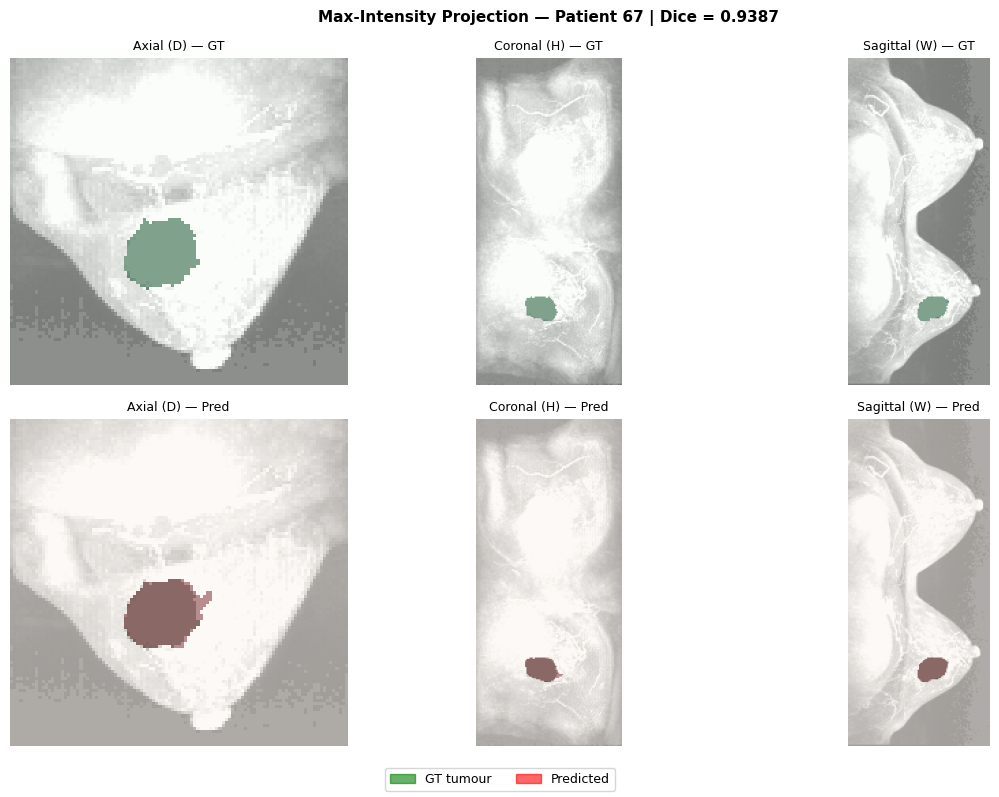

Saved: outputs/patient67_mip.png

--- Best prediction 3D render ---


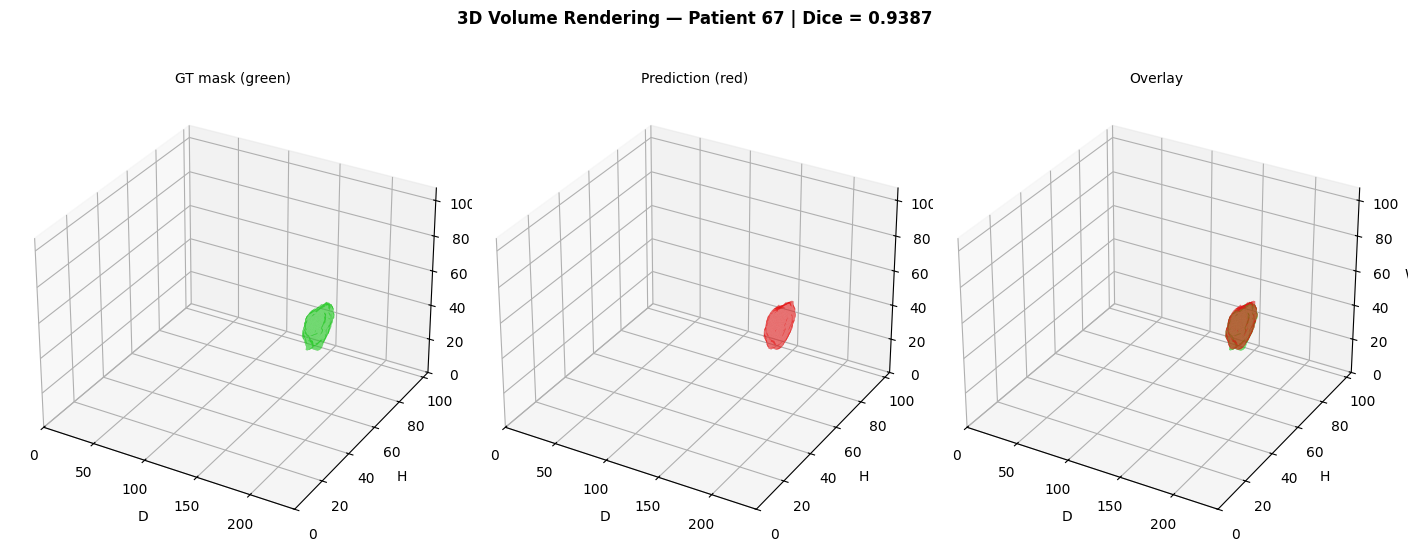

Saved: outputs/patient67_3d_render.png

--- Median prediction MIP ---


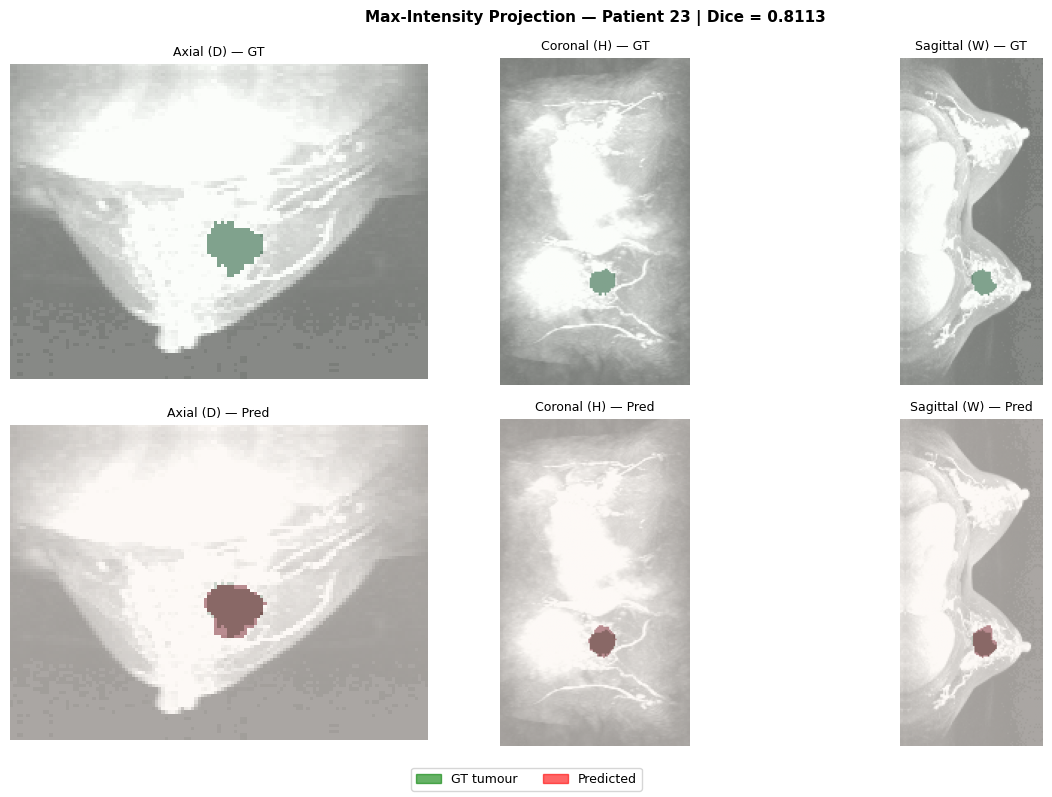

Saved: outputs/patient23_mip.png

--- Median prediction 3D render ---


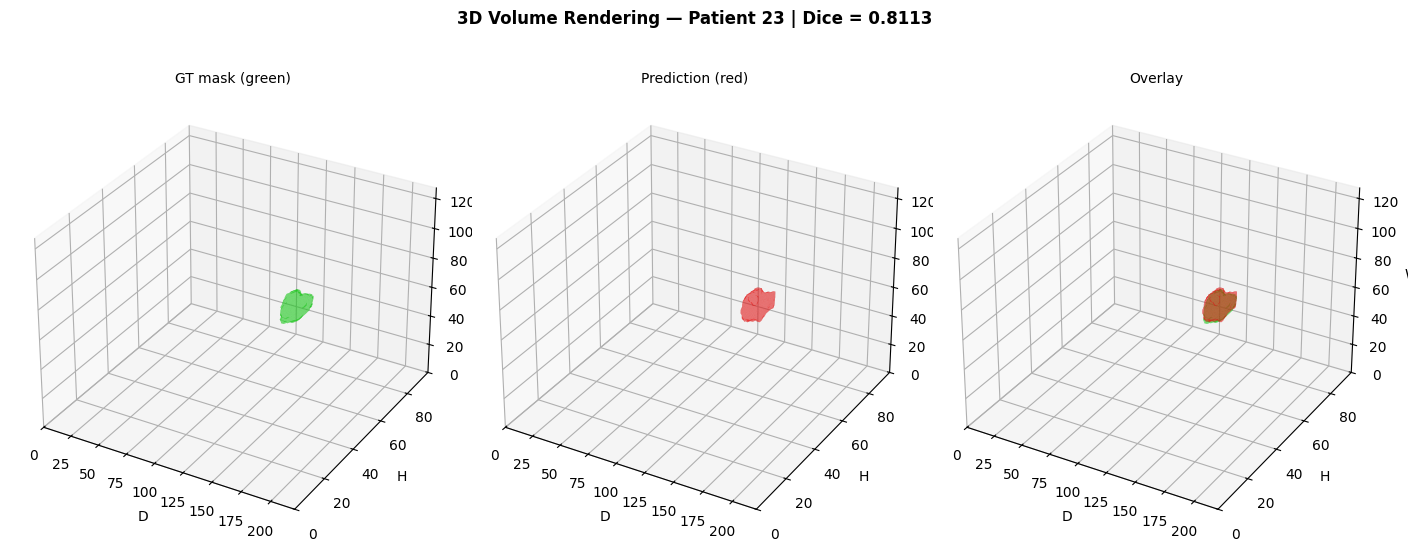

Saved: outputs/patient23_3d_render.png


In [14]:
# ============================================================
# CELL 10 — 3D volume rendering: GT vs prediction
# Uses max-intensity projection (MIP) across 3 axes
# ============================================================
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure

def plot_3d_masks(gt_mask, pred_mask, patient_id, dice):
    """
    3D surface rendering using marching cubes.
    Shows GT (green) and prediction (red) side by side.
    """
    fig = plt.figure(figsize=(14, 6))
    fig.suptitle(
        f'3D Volume Rendering — Patient {patient_id} | Dice = {dice:.4f}',
        fontsize=12, fontweight='bold'
    )

    def add_surface(ax, mask, color, title):
        if mask.sum() < 10:
            ax.text(0.5, 0.5, 0.5, 'No prediction', ha='center', va='center')
            ax.set_title(title)
            return
        try:
            verts, faces, _, _ = measure.marching_cubes(mask.astype(float), level=0.5)
            mesh = Poly3DCollection(verts[faces], alpha=0.4)
            mesh.set_facecolor(color)
            mesh.set_edgecolor('none')
            ax.add_collection3d(mesh)
            ax.set_xlim(0, mask.shape[0])
            ax.set_ylim(0, mask.shape[1])
            ax.set_zlim(0, mask.shape[2])
        except Exception:
            ax.text(0.5, 0.5, 0.5, 'Render failed', ha='center', va='center')
        ax.set_xlabel('D'); ax.set_ylabel('H'); ax.set_zlabel('W')
        ax.set_title(title, fontsize=10)

    ax1 = fig.add_subplot(131, projection='3d')
    add_surface(ax1, gt_mask,   color=[0.1, 0.8, 0.1], title='GT mask (green)')

    ax2 = fig.add_subplot(132, projection='3d')
    add_surface(ax2, pred_mask, color=[0.9, 0.1, 0.1], title='Prediction (red)')

    # Overlay view
    ax3 = fig.add_subplot(133, projection='3d')
    add_surface(ax3, gt_mask,   color=[0.1, 0.8, 0.1], title='Overlay (GT=green, Pred=red)')
    add_surface(ax3, pred_mask, color=[0.9, 0.1, 0.1], title='Overlay')

    plt.tight_layout()
    save_path = f'outputs/patient{patient_id}_3d_render.png'
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

# Also show MIP (max intensity projection) — simpler and always works
def plot_mip(cache_entry):
    """Max-intensity projection of GT and pred across all 3 axes."""
    gt   = cache_entry['gt'].astype(float)
    pred = cache_entry['pred'].astype(float)
    img  = cache_entry['image'][1]  # P2 channel
    pid  = cache_entry['patient_id']
    dice = cache_entry['dice']

    fig, axes = plt.subplots(2, 3, figsize=(12, 8))
    fig.suptitle(f'Max-Intensity Projection — Patient {pid} | Dice = {dice:.4f}',
                 fontsize=11, fontweight='bold')

    axis_names = ['Axial (D)', 'Coronal (H)', 'Sagittal (W)']
    for col, axis in enumerate([0, 1, 2]):
        mip_img  = img.max(axis=axis)
        mip_gt   = gt.max(axis=axis)
        mip_pred = pred.max(axis=axis)

        # Row 0: GT overlay
        ax = axes[0, col]
        ax.imshow(mip_img, cmap='gray')
        if mip_gt.max() > 0:
            ax.imshow(mip_gt,   cmap='Greens', alpha=0.5, vmin=0, vmax=1)
        ax.set_title(f'{axis_names[col]} — GT', fontsize=9)
        ax.axis('off')

        # Row 1: Prediction overlay
        ax = axes[1, col]
        ax.imshow(mip_img, cmap='gray')
        if mip_gt.max() > 0:
            ax.imshow(mip_gt,   cmap='Greens', alpha=0.35, vmin=0, vmax=1)
        if mip_pred.max() > 0:
            ax.imshow(mip_pred, cmap='Reds',   alpha=0.45, vmin=0, vmax=1)
        ax.set_title(f'{axis_names[col]} — Pred', fontsize=9)
        ax.axis('off')

    handles = [
        mpatches.Patch(color='green', alpha=0.6, label='GT tumour'),
        mpatches.Patch(color='red',   alpha=0.6, label='Predicted'),
    ]
    fig.legend(handles=handles, loc='lower center', ncol=2, fontsize=9)
    plt.tight_layout(rect=[0, 0.04, 1, 1])
    save_path = f'outputs/patient{pid}_mip.png'
    plt.savefig(save_path, dpi=100, bbox_inches='tight')
    plt.show()
    print(f'Saved: {save_path}')

# Run 3D rendering for best and worst cases
for entry, label in [(sorted_cache[-1], 'Best'), (sorted_cache[n//2], 'Median')]:
    print(f'\n--- {label} prediction MIP ---')
    plot_mip(entry)
    print(f'\n--- {label} prediction 3D render ---')
    plot_3d_masks(entry['gt'], entry['pred'], entry['patient_id'], entry['dice'])

In [11]:
# ============================================================
# CELL 11 — Per-patient evaluation table
# ============================================================
df = pd.DataFrame(results)
df['dice']       = df['dice'].round(4)
df['iou']        = df['iou'].round(4)
df['detected']   = df['detected'].map({True: 'Yes', False: 'No'})
df['has_tumor']  = df['has_tumor'].map({True: 'Yes', False: 'No'})

df_display = df[['patient_id','dice','iou','gt_voxels','pred_voxels','has_tumor','detected']]
df_display = df_display.sort_values('dice', ascending=False).reset_index(drop=True)

print('Per-patient test results (sorted by Dice):')
print('='*65)

# Color rows by Dice
def color_dice(val):
    if val >= 0.7:   return 'background-color: #c8e6c9'
    elif val >= 0.5: return 'background-color: #fff9c4'
    elif val >= 0.3: return 'background-color: #ffe0b2'
    else:            return 'background-color: #ffcdd2'

styled = df_display.style.map(color_dice, subset=['dice'])
display(styled)

# Save CSV
df_display.to_csv(os.path.join(PROJECT_ROOT, 'outputs', 'test_evaluation.csv'), index=False)
print('\nSaved: outputs/test_evaluation.csv')

# Quick summary stats
tumor_mask = df['has_tumor'] == 'Yes'
print(f'\n  Summary:')
print(f'  Mean Dice (tumor patients) : {df.loc[tumor_mask, "dice"].mean():.4f}')
print(f'  Std Dice                   : {df.loc[tumor_mask, "dice"].std():.4f}')
print(f'  Median Dice                : {df.loc[tumor_mask, "dice"].median():.4f}')
print(f'  Best Dice                  : {df.loc[tumor_mask, "dice"].max():.4f}')
print(f'  Worst Dice                 : {df.loc[tumor_mask, "dice"].min():.4f}')

Per-patient test results (sorted by Dice):


,patient_id,dice,iou,gt_voxels,pred_voxels,has_tumor,detected
0,67,0.938700,0.884400,4364,4653,Yes,Yes
1,78,0.898100,0.815000,1984,2118,Yes,Yes
2,20,0.848900,0.737500,2140,2567,Yes,Yes
3,66,0.840400,0.724700,2496,3418,Yes,Yes
4,54,0.832600,0.713200,19032,22757,Yes,Yes
5,15,0.812400,0.684000,4373,5322,Yes,Yes
6,42,0.811600,0.683000,16349,13450,Yes,Yes
7,23,0.811300,0.682600,1921,2563,Yes,Yes
8,102,0.801000,0.668100,2600,3622,Yes,Yes
9,177,0.793400,0.657600,2600,1887,Yes,Yes



Saved: outputs/test_evaluation.csv

  Summary:
  Mean Dice (tumor patients) : 0.6482
  Std Dice                   : 0.2423
  Median Dice                : 0.7089
  Best Dice                  : 0.9387
  Worst Dice                 : 0.0000


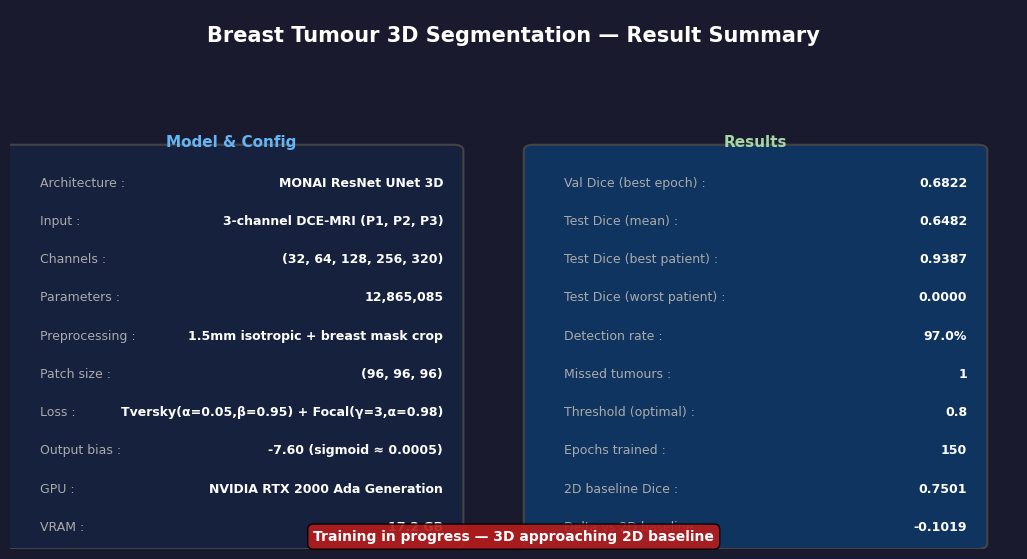

Saved: outputs/summary_card_3d.png

  3D Pipeline Complete
  Test Dice     : 0.6482
  2D baseline   : 0.7501
  Detection rate: 97.0%
  Next step     : Train DynUNet → ensemble_3model.py


In [12]:
# ============================================================
# CELL 14 — Full summary card
# ============================================================

# Gather all numbers
tumor_results  = [r for r in results if r['has_tumor']]
mean_dice      = np.mean([r['dice'] for r in tumor_results])
best_dice      = max([r['dice'] for r in tumor_results])
worst_dice     = min([r['dice'] for r in tumor_results])
det_rate       = 100 * sum(r['detected'] for r in tumor_results) / len(tumor_results)
missed         = sum(1 for r in tumor_results if not r['detected'])
total_params   = sum(p.numel() for p in model.parameters())

history_loaded = os.path.exists(HISTORY_FILE)
if history_loaded:
    h = np.load(HISTORY_FILE, allow_pickle=True).item()
    best_val_dice = max(h['val_dice'])
    total_epochs  = len(h['val_dice'])
    final_loss    = h['val_loss'][-1]
else:
    best_val_dice = total_epochs = final_loss = 'N/A'

fig, ax = plt.subplots(figsize=(13, 7))
ax.axis('off')
fig.patch.set_facecolor('#1a1a2e')

# Title
ax.text(0.5, 0.97, 'Breast Tumour 3D Segmentation — Result Summary',
        ha='center', va='top', transform=ax.transAxes,
        fontsize=15, fontweight='bold', color='white')

# Model info box
model_info = [
    ('Architecture',  'MONAI ResNet UNet 3D'),
    ('Input',         '3-channel DCE-MRI (P1, P2, P3)'),
    ('Channels',      str(MODEL_CONFIG['channels'])),
    ('Parameters',    f'{total_params:,}'),
    ('Preprocessing', '1.5mm isotropic + breast mask crop'),
    ('Patch size',    str(PATCH_SIZE)),
    ('Loss',          'Tversky(α=0.05,β=0.95) + Focal(γ=3,α=0.98)'),
    ('Output bias',   '-7.60 (sigmoid ≈ 0.0005)'),
    ('GPU',           gpu_name),
    ('VRAM',          f'{vram_gb:.1f} GB'),
]

# Results box
result_info = [
    ('Val Dice (best epoch)',    f'{best_val_dice:.4f}' if isinstance(best_val_dice, float) else best_val_dice),
    ('Test Dice (mean)',         f'{mean_dice:.4f}'),
    ('Test Dice (best patient)', f'{best_dice:.4f}'),
    ('Test Dice (worst patient)',f'{worst_dice:.4f}'),
    ('Detection rate',           f'{det_rate:.1f}%'),
    ('Missed tumours',           f'{missed}'),
    ('Threshold (optimal)',      f'{INFER_THRESHOLD}'),
    ('Epochs trained',           str(total_epochs)),
    ('2D baseline Dice',         f'{BASELINE_2D_DICE}'),
    ('Delta vs 2D baseline',     f'{mean_dice - BASELINE_2D_DICE:+.4f}'),
]

def draw_info_box(ax, title, items, x_start, y_start, box_color, title_color):
    # Box background
    rect = mpatches.FancyBboxPatch((x_start-0.02, y_start-0.03),
                                    0.44, 0.02 + len(items)*0.071,
                                    boxstyle='round,pad=0.01',
                                    facecolor=box_color, edgecolor='#444', linewidth=1.5,
                                    transform=ax.transAxes, zorder=0)
    ax.add_patch(rect)
    ax.text(x_start + 0.20, y_start + len(items)*0.071 - 0.01, title,
            ha='center', va='bottom', transform=ax.transAxes,
            fontsize=11, fontweight='bold', color=title_color)
    for i, (label, val) in enumerate(items):
        y = y_start + (len(items) - 1 - i) * 0.071
        ax.text(x_start + 0.01, y, label + ' :',
                ha='left', va='center', transform=ax.transAxes,
                fontsize=9, color='#aaa')
        ax.text(x_start + 0.41, y, str(val),
                ha='right', va='center', transform=ax.transAxes,
                fontsize=9, color='white', fontweight='bold')

draw_info_box(ax, 'Model & Config', model_info,
              0.02, 0.04, '#16213e', '#64b5f6')
draw_info_box(ax, 'Results', result_info,
              0.54, 0.04, '#0f3460', '#a5d6a7')

# Status banner
status_color = '#1b5e20' if mean_dice >= BASELINE_2D_DICE else '#b71c1c'
status_text  = ('3D model surpassed 2D baseline' if mean_dice >= BASELINE_2D_DICE
                else 'Training in progress — 3D approaching 2D baseline')
ax.text(0.5, 0.01, status_text,
        ha='center', va='bottom', transform=ax.transAxes,
        fontsize=10, fontweight='bold', color='white',
        bbox=dict(boxstyle='round,pad=0.4', facecolor=status_color, alpha=0.9))

plt.savefig(os.path.join(PROJECT_ROOT, 'outputs', 'summary_card_3d.png'), dpi=130, bbox_inches='tight',
            facecolor='#1a1a2e')
plt.show()

print('Saved: outputs/summary_card_3d.png')
print('\n' + '='*55)
print('  3D Pipeline Complete')
print('='*55)
print(f'  Test Dice     : {mean_dice:.4f}')
print(f'  2D baseline   : {BASELINE_2D_DICE}')
print(f'  Detection rate: {det_rate:.1f}%')
print(f'  Next step     : Train DynUNet → ensemble_3model.py')